### Mathematical Operations With Images
Continuing from our previous notebook, we will take one step further in this notebook where we explore how to apply fundamental mathematical operations with images using `open-cv` and other associated libraries in Python.

We will cover some fundamental image processing operations like:
- Blending
- Differencing
- Masking
- Superimposing
- Sharpening and Darkening

#### Setup and Installation

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### Sample Images
We will use a few more new sample images

In [2]:
image1 = cv2.imread('data/bicycle.png')
image2 = cv2.imread('data/dolphin.png')

In [3]:
# Utility function to display images
def show_image(img, fig_size = None):
    print(img.shape)
    img = img.astype('uint8')

    if fig_size is not None:
        plt.figure(figsize=fig_size)

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.show()

(320, 500, 3)


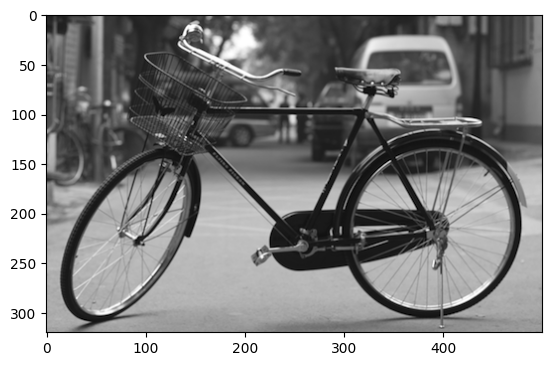

(320, 500, 3)


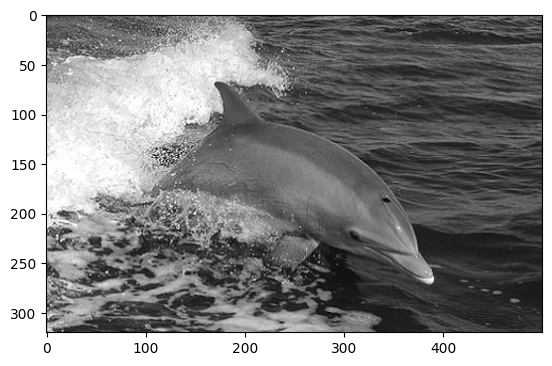

In [4]:
show_image(image1)
show_image(image2)

#### Basic Mathematical Operations

As discussed earlier, images are numerical matrices. Hence, they support basic arithmatic operations like addition, substraction and etc.

Let us take these two images and simply add them, then add the averaged image and then add and average the result

(320, 500, 3)


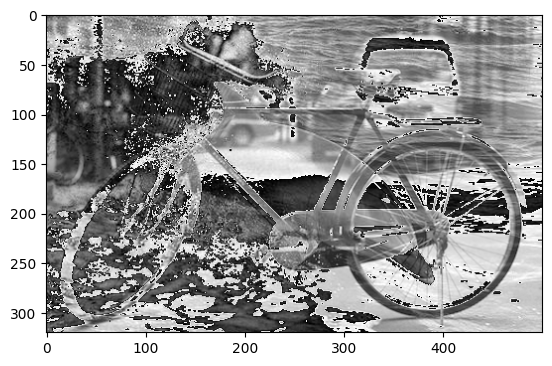

In [8]:
# Addition
added_image1 = image1 + image2
show_image(added_image1)

(320, 500, 3)


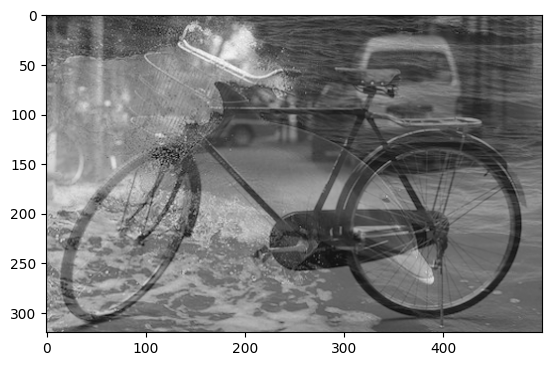

In [9]:
# Adding averaged images
added_image2 = image1//2 + image2//2
show_image(added_image2)

(320, 500, 3)


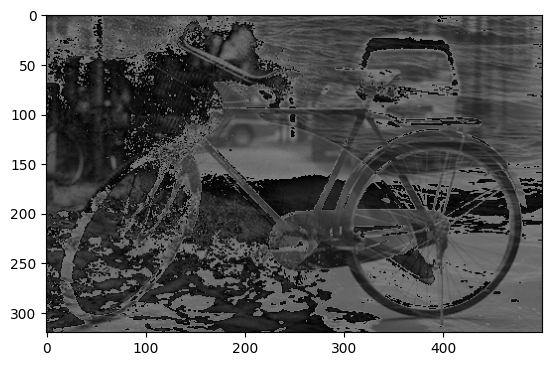

In [10]:
# Averging added image
show_image(added_image1//2)

Let us carefully analyse these three images and understand why there is a difference.

To understand the difference in more depth, we need to keep in mind that the underlying data type is actually `uint8`

Now, let us take a simple analogy through simple variables

In [11]:
# Let's try this now?
a = np.array(200).astype('uint8')
b = np.array(100).astype('uint8')

c = a/2 + b/2
d = (a + b)/2

Is c = d? Or can you guess what the values of c and d will be?

In [12]:
print(c == d)

# what are the values of c and d?
print('Value of c is:', c)
print('Value of d is:', d)

False
Value of c is: 150.0
Value of d is: 22.0


As we can see that the values of variables `c` and `d` are different due to the data type. It is because of the `uint8` data type, the results of the three images are not same.

##### Multiplication
Next, let us try out a multiplication operation

In [13]:
# Multiplication
def normalize_image(img):
    img = img.astype('float')
    max_value = np.max(img)

    return img/max_value

Orginal Image
(320, 500, 3)


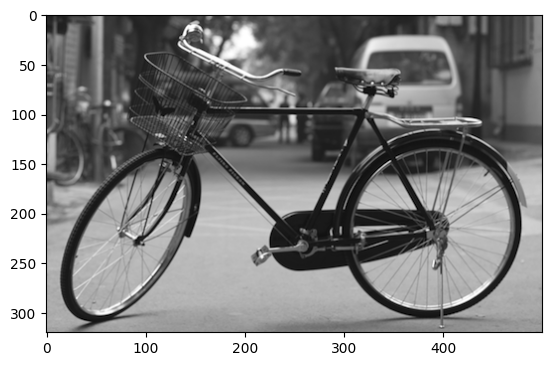

Image multiplied with 1.5
(320, 500, 3)


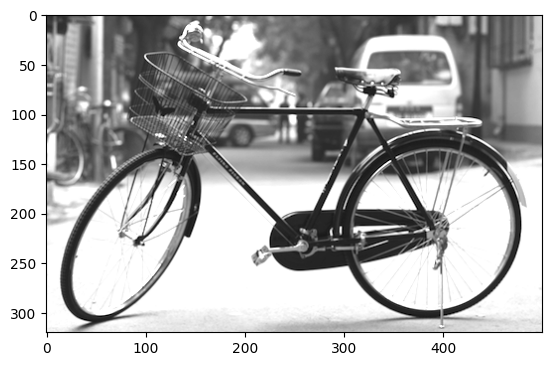

In [14]:
print('Orginal Image')
show_image(image1)
print('Image multiplied with 1.5')
show_image(np.clip((image1.astype('float') * 1.5), 0., 255.).astype('uint8'))

Does the new image looks brighter? Yes, it does as multiplying pixel values will bring it closer to 255, which is the brightest pixel. But did you notice we had to use `np.clip()` to keep all the pixel values between 0 and 255? Otherwise, when we change it back to unsigned int, the image will look distorted.

*So, as a quick task, why don't you try removing `np.clip()` and see how the image is looking!*

#### Image Blending

Image blending was a popular trick for most photoshop specialists to bring interesting visual effects. It is nothing but a combination of some of the arithmatic image operators that we saw. So, let's try blending with two new images

(500, 500, 3)


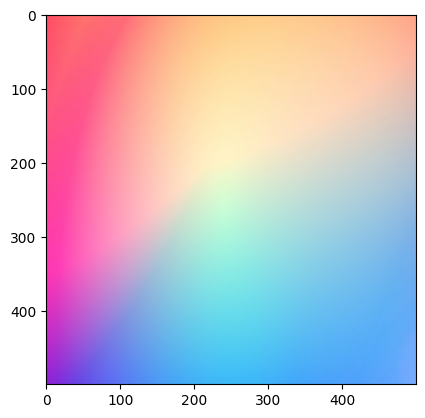

(500, 500, 3)


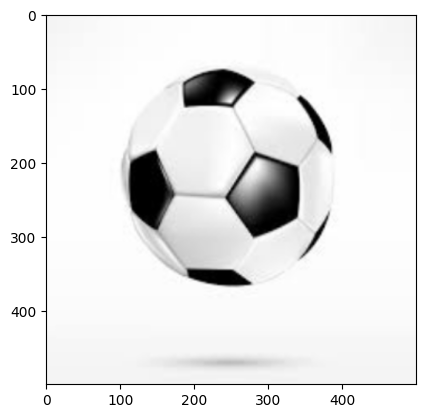

In [16]:
image3 = cv2.resize(cv2.imread('data/blend1.PNG'), (500,500))
image4 = cv2.resize(cv2.imread('data/football.png'), (500,500))
show_image(image3)
show_image(image4)

(500, 500, 3)


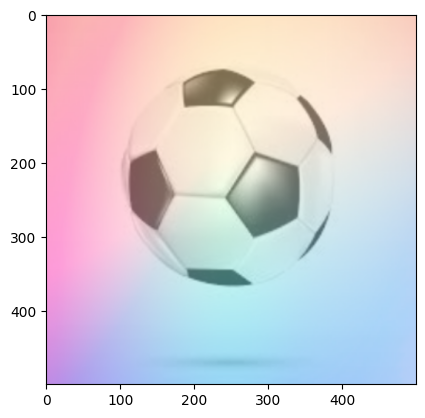

In [31]:
# Our own blending function
def blend_images(img1, img2, blending_ratio):
    return blending_ratio * img1 + (1. - blending_ratio) * img2

# let's blend both the images equally (try changing the ratios)
blended_img = blend_images(image3, image4, 0.5)
show_image(blended_img)

(500, 500, 3)


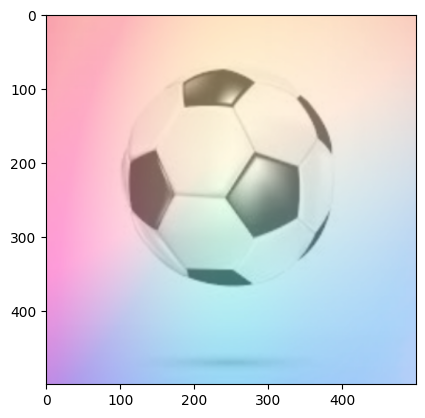

In [ ]:
# addWeighted(src1, alpha, src2, beta, gamma)
# dst = src1 * alpha + src2 * beta + gamma
opencv_blended = cv2.addWeighted(image3, 0.5, image4, 0.5, 0)   
show_image(opencv_blended) 

#### Image Difference

Image difference can actually be thought as more than just mere image subtraction. But can be an important technique to localize difference in two images. So, let's try our hand at image differencing using the fruit images we saw before.

(258, 320, 3)


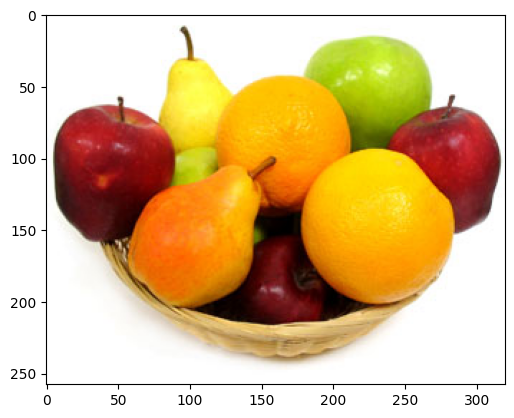

(258, 320, 3)


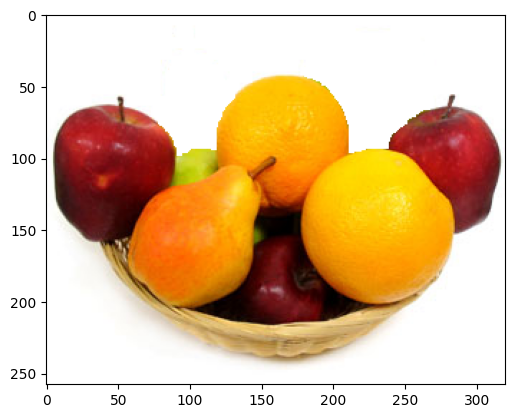

In [34]:
image5 = cv2.imread('data/fruit.png')
image6 = cv2.imread('data/fruit2.png')

show_image(image5)
show_image(image6)

In [35]:
# Creating a copy of the images as we will be playing with the image pixel values
# and accidently we don't want any changes to the original images
new_img = image6.copy()
orig_img = image5.copy()

# find the difference image
difference_img = cv2.subtract(new_img, orig_img)
gray = cv2.cvtColor(difference_img, cv2.COLOR_BGR2GRAY)
difference_img[gray > 5] = [0, 0, 255]

Displaying the highlighted missing objects
(258, 320, 3)


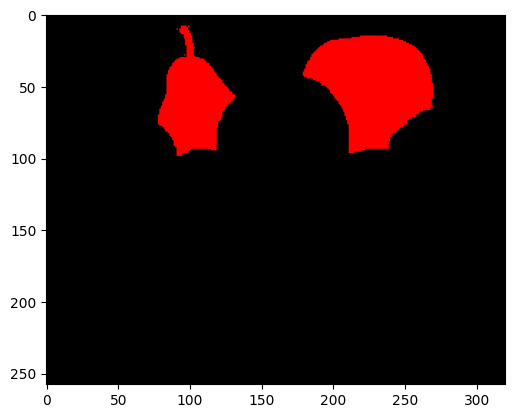

In [ ]:
# Displaying the highlighted missing objects
print('Displaying the highlighted missing objects')
show_image(difference_img)

#### Masking
Now, let us mask the missing item and superimpose on the base image

Localized the new images with missing objects
(258, 320, 3)


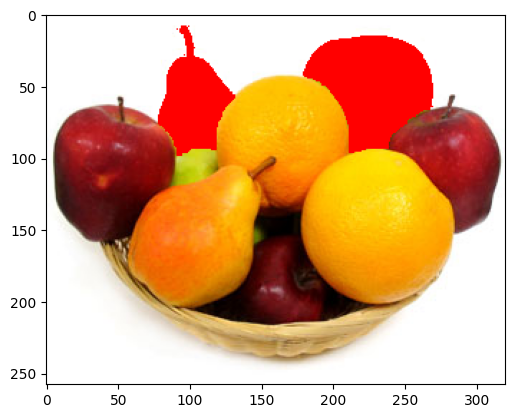

Original image for comparison
(258, 320, 3)


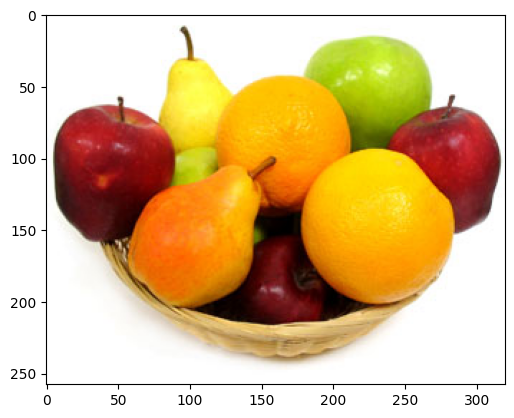

In [ ]:
# adding the coloured mask to the new image, to localize the missing objects
new_img[gray > 5] = [0, 0, 255]

print('Localised the new images with missing objects')
show_image(new_img)
print('Original image for comparison')
show_image(orig_img)

#### Bitwise Operations

Bitwise operations operate directly on the binary representation of pixel intensity values, applying logical operations such as AND, OR, and NOT at the bit level. In images, they are commonly used for tasks such as masking, region selection, and combining images based on pixel-level conditions.

Read more about bitwise operations [here](https://en.wikipedia.org/wiki/Bitwise_operation)

Bitwise NOT converts all black pixels to white and vice versa
(258, 320)


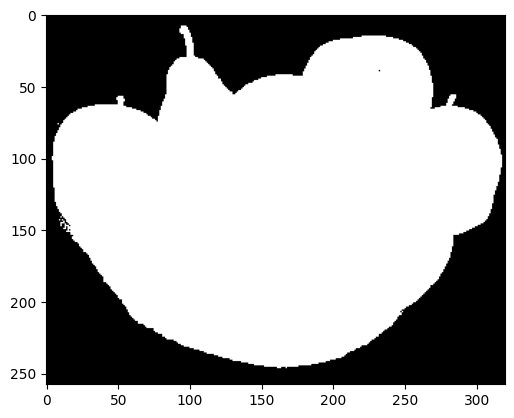

(258, 320)


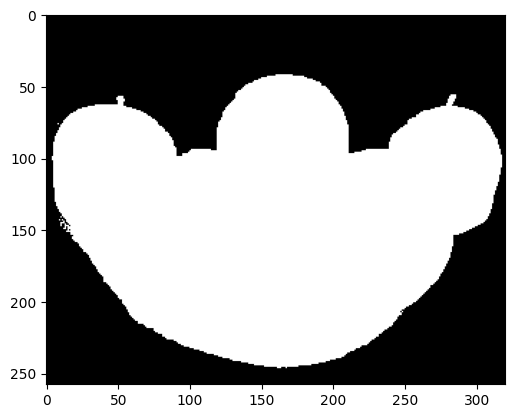

Bitwise AND operations on the masks: which takes the common pixels in both the images
(258, 320)


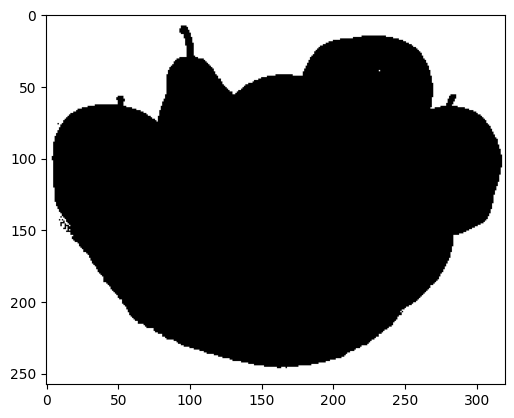

Bitwise OR operations on the masks: which takes unique pixels from both the images
(258, 320)


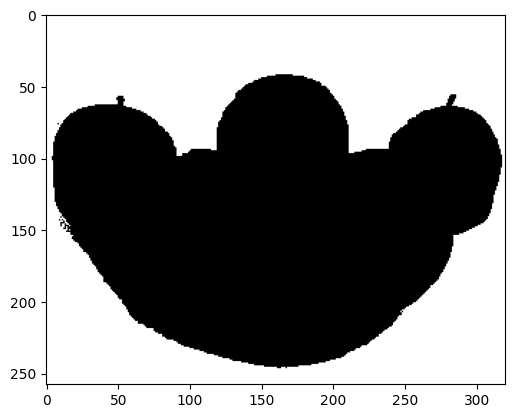

In [38]:
# Now create a mask of logo and create its inverse mask also
gray_orig = cv2.cvtColor(orig_img,cv2.COLOR_BGR2GRAY)
_, mask1 = cv2.threshold(gray_orig, 245, 255, cv2.THRESH_BINARY)

gray_new = cv2.cvtColor(image6,cv2.COLOR_BGR2GRAY)
_, mask2 = cv2.threshold(gray_new, 245, 255, cv2.THRESH_BINARY)

print('Bitwise NOT converts all black pixels to white and vice versa')
mask_inv1 = cv2.bitwise_not(mask1)
mask_inv2 = cv2.bitwise_not(mask2)
show_image(mask_inv1)
show_image(mask_inv2)


print('Bitwise AND operations on the masks: which takes the common pixels in both the images')
bit_and = cv2.bitwise_and(mask1, mask2)
show_image(bit_and)

print('Bitwise OR operations on the masks: which takes unique pixels from both the images')
bit_or = cv2.bitwise_or(mask1, mask2)
show_image(bit_or)

let's see a fun application of bitwise image operations

(288, 512)


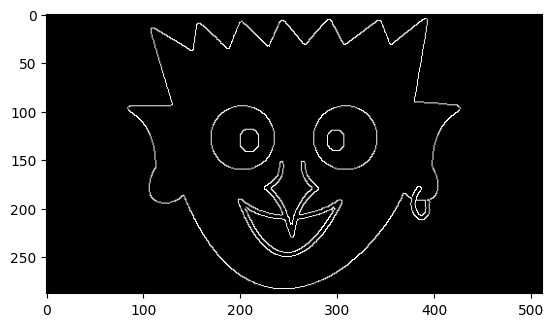

(288, 512)


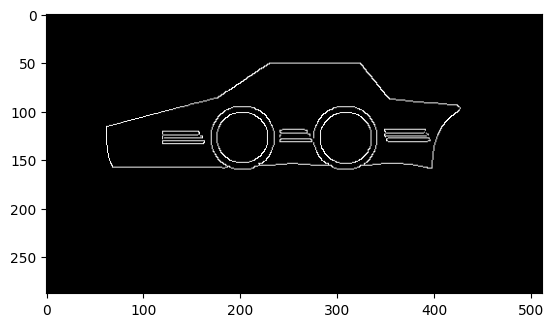

(288, 512)


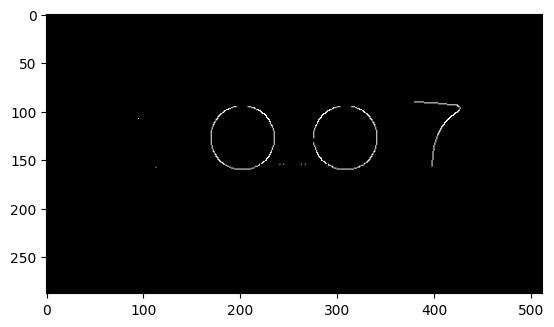

In [39]:
bit1 = cv2.imread('data/bit1.png', 0)
bit2 = cv2.imread('data/bit2.png', 0)

show_image(bit1)
show_image(bit2)

bit_and2 = cv2.bitwise_and(bit1, bit2)
show_image(bit_and2)

These types of masking technique and bitwise operations were actually used to hide secret codes and information through images

This brings us to the end of this tutorial. We explored various mathematical operation with images such as blending, differencing, bitwise operations, sharpening, darkening etc.